<a href="https://colab.research.google.com/github/AlviAdor/CNN-Development-on-Custom-Dataset/blob/main/CNN_22-46936-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Development on Custom Dataset

**Student ID:** _22-46936-1_

**Dataset:** AFHQ (Animal Faces) — https://www.kaggle.com/datasets/andrewmvd/animal-faces

3 classes: `cat`, `dog`, `wildlife`. Comes with a pre-made `train/` and `val/` split.


## 1. Import Libraries

In [1]:
import os
import copy
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 2. Load and Explore Dataset

Download AFHQ with `kagglehub`. This needs a Kaggle API token (`kaggle.json`)


In [2]:
!pip install -q kagglehub
import kagglehub
from google.colab import files

uploaded = files.upload()
os.makedirs("/root/.kaggle", exist_ok=True)
for fname in uploaded:
    os.rename(fname, "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

dataset_path = kagglehub.dataset_download("andrewmvd/animal-faces")
print("Dataset downloaded to:", dataset_path)


Saving kaggle.json to kaggle.json


100%|██████████| 696M/696M [00:32<00:00, 22.2MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/andrewmvd/animal-faces/versions/1


In [3]:
train_dir = os.path.join(dataset_path, "afhq", "train")
test_dir = os.path.join(dataset_path, "afhq", "val")

class_names = sorted(os.listdir(train_dir))
print("Classes:", class_names)

train_counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in class_names}
test_counts = {c: len(os.listdir(os.path.join(test_dir, c))) for c in class_names}
pd.DataFrame({"train": train_counts, "test": test_counts})


Classes: ['cat', 'dog', 'wild']


,train,test
cat,5153,500
dog,4739,500
wild,4738,500


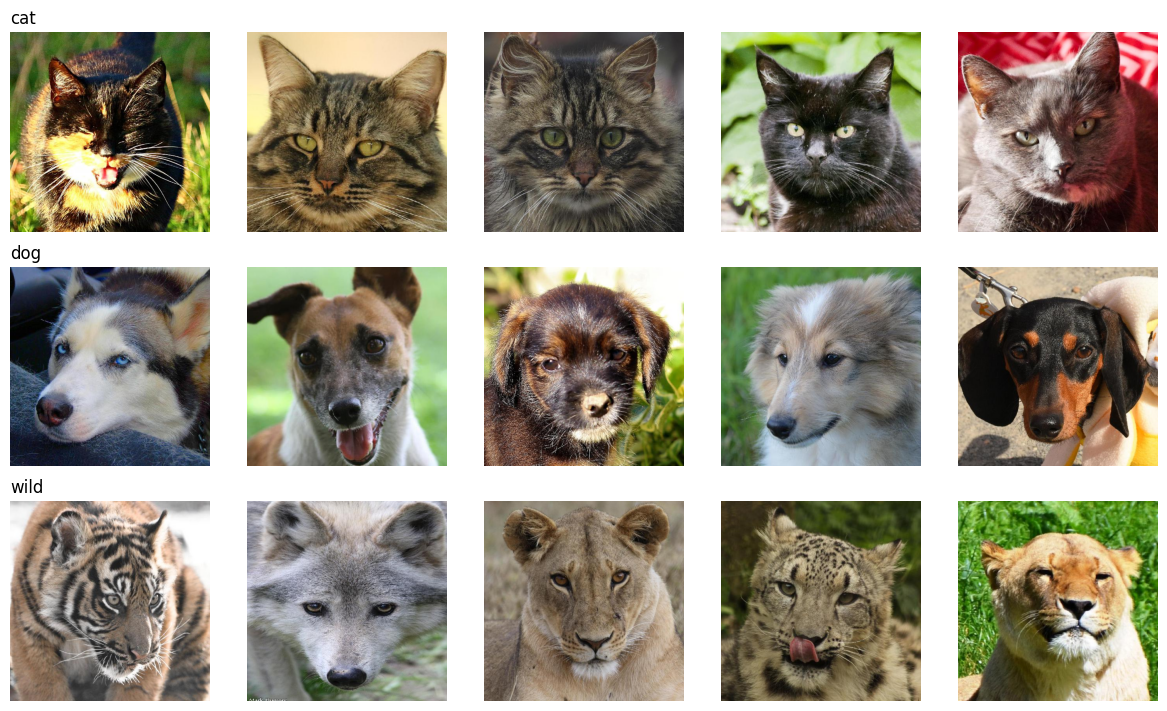

In [4]:
# Sample images from each class
fig, axes = plt.subplots(len(class_names), 5, figsize=(12, 2.4 * len(class_names)))
for row, cls in enumerate(class_names):
    cls_dir = os.path.join(train_dir, cls)
    for col, fname in enumerate(os.listdir(cls_dir)[:5]):
        img = plt.imread(os.path.join(cls_dir, fname))
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
    axes[row, 0].set_title(cls, loc="left")
plt.tight_layout()
plt.show()


## 3. Data Preprocessing & Augmentation

Images are resized to 128x128 (fast to train, still enough detail for faces). Training data is
augmented with a horizontal flip and small rotation. A 10% validation split is taken from the
train folder; the provided `val/` folder is kept aside as the test set.


In [5]:
IMG_SIZE = 128
BATCH_SIZE = 32

mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])


In [6]:
full_train_aug = datasets.ImageFolder(train_dir, transform=train_transform)
full_train_eval = datasets.ImageFolder(train_dir, transform=eval_transform)

n_val = int(0.1 * len(full_train_aug))
n_train = len(full_train_aug) - n_val
train_idx, val_idx = random_split(range(len(full_train_aug)), [n_train, n_val],
                                   generator=torch.Generator().manual_seed(42))

train_dataset = torch.utils.data.Subset(full_train_aug, train_idx.indices)
val_dataset = torch.utils.data.Subset(full_train_eval, val_idx.indices)
test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

print("Train:", len(train_dataset), "Val:", len(val_dataset), "Test:", len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


Train: 13167 Val: 1463 Test: 1500


## 4. Define CNN Architecture

A simple 4-block CNN (Conv -> BatchNorm -> ReLU -> MaxPool), followed by a fully connected
classifier head with dropout for regularization.


In [7]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = CustomCNN(num_classes=len(class_names)).to(device)
print(model)


CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

In [8]:
!pip install -q torchsummary
from torchsummary import summary
summary(model, input_size=(3, IMG_SIZE, IMG_SIZE))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
         MaxPool2d-4           [-1, 32, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]          18,496
       BatchNorm2d-6           [-1, 64, 64, 64]             128
              ReLU-7           [-1, 64, 64, 64]               0
         MaxPool2d-8           [-1, 64, 32, 32]               0
            Conv2d-9          [-1, 128, 32, 32]          73,856
      BatchNorm2d-10          [-1, 128, 32, 32]             256
             ReLU-11          [-1, 128, 32, 32]               0
        MaxPool2d-12          [-1, 128, 16, 16]               0
           Conv2d-13          [-1, 256, 16, 16]         295,168
      BatchNorm2d-14          [-1, 256,

## 5. Training Loop with Validation

**Hyperparameters:**
- Optimizer: Adam, lr=1e-3, weight_decay=1e-4 (adaptive learning rate, faster convergence than SGD)
- Loss: CrossEntropyLoss (standard for multi-class classification)
- Batch size: 32
- Epochs: 15
- Regularization: dropout + weight decay to reduce overfitting


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
NUM_EPOCHS = 15


In [10]:
def run_epoch(model, loader, train=False):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.set_grad_enabled(train):
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += inputs.size(0)
    return total_loss / total, correct / total


In [11]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0
best_weights = copy.deepcopy(model.state_dict())

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, train=True)
    val_loss, val_acc = run_epoch(model, val_loader, train=False)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weights = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch}/{NUM_EPOCHS} - train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} "
          f"val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")

model.load_state_dict(best_weights)
print("Best validation accuracy:", best_val_acc)


Epoch 1/15 - train_loss: 0.5320 train_acc: 0.8359 val_loss: 0.2336 val_acc: 0.9070
Epoch 2/15 - train_loss: 0.1721 train_acc: 0.9376 val_loss: 0.1053 val_acc: 0.9631
Epoch 3/15 - train_loss: 0.1257 train_acc: 0.9560 val_loss: 0.0856 val_acc: 0.9740
Epoch 4/15 - train_loss: 0.1027 train_acc: 0.9648 val_loss: 0.0910 val_acc: 0.9713
Epoch 5/15 - train_loss: 0.0846 train_acc: 0.9708 val_loss: 0.0603 val_acc: 0.9802
Epoch 6/15 - train_loss: 0.0795 train_acc: 0.9720 val_loss: 0.0765 val_acc: 0.9713
Epoch 7/15 - train_loss: 0.0753 train_acc: 0.9738 val_loss: 0.0573 val_acc: 0.9809
Epoch 8/15 - train_loss: 0.0659 train_acc: 0.9777 val_loss: 0.0838 val_acc: 0.9774
Epoch 9/15 - train_loss: 0.0586 train_acc: 0.9806 val_loss: 0.0414 val_acc: 0.9856
Epoch 10/15 - train_loss: 0.0578 train_acc: 0.9796 val_loss: 0.0924 val_acc: 0.9610
Epoch 11/15 - train_loss: 0.0534 train_acc: 0.9820 val_loss: 0.0413 val_acc: 0.9836
Epoch 12/15 - train_loss: 0.0506 train_acc: 0.9830 val_loss: 0.0574 val_acc: 0.9815
E

## 6. Evaluate Model on Test Set

In [12]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        preds = model(inputs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds, all_labels = np.array(all_preds), np.array(all_labels)

print("Test Accuracy:", accuracy_score(all_labels, all_preds))
print("Precision (weighted):", precision_score(all_labels, all_preds, average="weighted"))
print("Recall (weighted):", recall_score(all_labels, all_preds, average="weighted"))
print("F1-score (weighted):", f1_score(all_labels, all_preds, average="weighted"))
print()
print(classification_report(all_labels, all_preds, target_names=class_names))


Test Accuracy: 0.9853333333333333
Precision (weighted): 0.9854252728250151
Recall (weighted): 0.9853333333333333
F1-score (weighted): 0.9853420353168592

              precision    recall  f1-score   support

         cat       0.99      0.99      0.99       500
         dog       0.97      0.99      0.98       500
        wild       0.99      0.98      0.98       500

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500



## 7. Visualizations

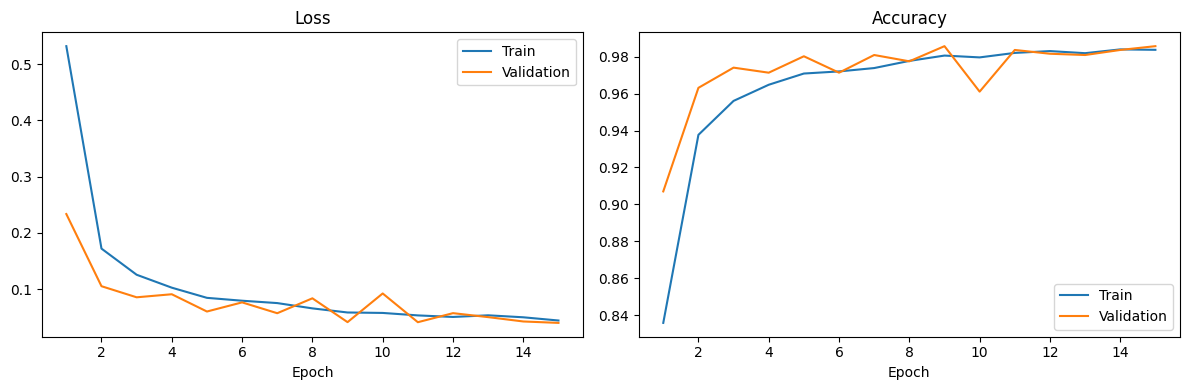

In [13]:
epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"], label="Validation")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"], label="Validation")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.tight_layout()
plt.show()


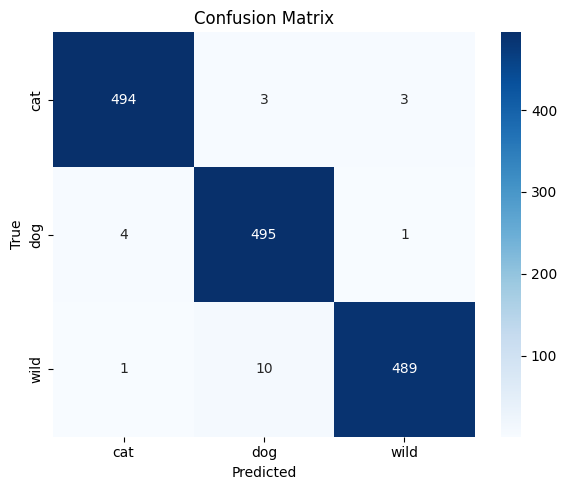

In [14]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## 8. Analysis & Discussion of Results

In [15]:
per_class_df = pd.DataFrame({
    "class": class_names,
    "precision": precision_score(all_labels, all_preds, average=None),
    "recall": recall_score(all_labels, all_preds, average=None),
    "f1_score": f1_score(all_labels, all_preds, average=None),
}).sort_values("f1_score", ascending=False).reset_index(drop=True)

print("Best performing class:", per_class_df.iloc[0]["class"])
print("Worst performing class:", per_class_df.iloc[-1]["class"])
per_class_df


Best performing class: cat
Worst performing class: dog


,class,precision,recall,f1_score
0,cat,0.989980,0.988,0.988989
1,wild,0.991886,0.978,0.984894
2,dog,0.974409,0.990,0.982143


Best performing class: cat (F1 = 0.989) — 494/500 correctly classified, with only 3 misclassified as dog and 3 as wild.

Worst performing class: dog (F1 = 0.982) — though dog has slightly lower precision, wild actually has the most misclassifications as a true class (11 total: 1→cat, 10→dog).

Most confused pair: wild → dog is the single largest source of error in the whole matrix — 10 wildlife images were misclassified as dog, compared to just 1–4 errors everywhere else in the matrix. This makes visual sense: several animals in the wildlife class (e.g. wolves, foxes) share strong facial structure similarities with domestic dogs — pointed ears, similar snout shape, and comparable fur texture — making them the hardest pair for the model to tell apart. In contrast, cat is cleanly separated from both other classes (only 6 total errors across both directions), which is why it comes out on top.


## 9. Save Trained Model

In [16]:
MODEL_PATH = "custom_cnn_afhq.pth"
torch.save(model.state_dict(), MODEL_PATH)

size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
print(f"Model saved to {MODEL_PATH} ({size_mb:.2f} MB)")


Model saved to custom_cnn_afhq.pth (17.50 MB)


In [17]:
# Reload example
loaded_model = CustomCNN(num_classes=len(class_names)).to(device)
loaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
loaded_model.eval()
print("Model reloaded successfully.")


Model reloaded successfully.


## Conclusions & Future Work

A custom 4-block CNN trained from scratch classified AFHQ's 3 animal-face categories (cat, dog, wild), reaching 98.53% test accuracy (weighted F1 = 0.985) on the held-out 1,500-image test set. The model converged quickly and stably, with validation accuracy climbing from 90.7% after epoch 1 to a best of 98.56% by epoch 15. Dropout (0.4/0.3) and weight decay (1e-4) helped keep the train/validation gap small throughout training, with no signs of significant overfitting.

The main source of error was confusion between wild and dog (10 wildlife images misclassified as dog), likely due to shared facial structure in some species (e.g. wolves, foxes) with domestic dogs. cat was the most cleanly separated class.


**Future work:** We can try transfer learning (e.g. VGG16) to see whether a pretrained backbone can close the remaining gap on the wild/dog confusion, tune hyperparameters further (learning rate, dropout rate), and use Grad-CAM to visualize which facial regions the model relies on for each class.
